# Replication of Wang's paper

## Preprocessing

Instead of using raw waveforms, the backbone takes mel-spectrograms as input. A mel-spectrogram is a visual representation of the spectrum of frequencies in a sound as they vary with time, adjusted to match how the human ear perceives pitch.

Step 1: Extract the attributes from each file (from attributes_00.csv)

Step 2: Convert the .wav files to mel-spectrograms.

Step 3: The mel-spectrogram is partitioned into $16\times16$ patches.

## Pass to the EAT model

Step 4: Pass the patches through the EAT Encoder, each patch outputs its own embedding containing deep representational info.

Step 5: Apply average pooling to all patch embeddings extracted by the model from one mel-spectrogram (corresponding to 1 audiofile). This results in a single vector (the embedding) that represents the core characteristics of that specific recording.

## Training phase

Classification task: 
The embeddings are fed into a Linear Classifier. The model is trained to classify the machine's attributes (e.g., its specific state or configuration) and/or its domain (source vs. target).

ArcFace loss:
Instead of a standard loss function, the system uses ArcFace loss. This adds a "margin" in the angular space, forcing the model to create highly compact and distinct clusters for normal machine sounds.

Optimization:
This process is done using either Full Fine-Tuning (updating all 88 million parameters) or LoRA (updating only small "low-rank" matrices) to adapt the pre-trained model to the specific DCASE dataset.









## EAT applied to specific machine
Here all the train files from the bearing machine from 2023 are processed. All the 1000 embedding are extracted and saved, together with a .csv file which contains the meta data of each audio file. In this file the file_name, feature_path, domain, and attribute_id are stored. The domain would be source or target and the attribute ID will be a number. For example for the bearing machine it has a velocity and location attribute. If the velocity is 1 and the location is A, it will receive the attribute ID 1. if the velocity is one and the location is B, it will receive the attribute ID 2, etc.

In [11]:
import os
import pandas as pd
import torch
import torchaudio
import soundfile as sf
import numpy as np
from tqdm import tqdm
from transformers import AutoModel

# Configure paths and parameters
# Parameters from huggingface: https://huggingface.co/worstchan/EAT-base_epoch30_finetune_AS2M/blob/main/config.json
year = "2023"
machine = "bearing"
data_dir = f"data/dcase{year}t2/dev_data/raw/{machine}/train"
output_dir = f"features/Prototype_single/dcase{year}t2/{machine}/features"
os.makedirs(output_dir, exist_ok=True)
target_length = 1024    # Recommended: 1024 for 10s audio
norm_mean = -4.268     
norm_std = 4.569

model_id = "worstchan/EAT-base_epoch30_finetune_AS2M"
model = AutoModel.from_pretrained(model_id, trust_remote_code=True).eval().cuda()

import os
import pandas as pd

# Load the attribute CSV
attr_df = pd.read_csv(f"data/dcase{year}t2/dev_data/raw/{machine}/attributes_00.csv")
attr_df['file_name_clean'] = attr_df['file_name'].apply(lambda x: os.path.basename(x))
feature_cols = [c for c in attr_df.columns if c not in ['file_name', 'file_name_clean']]
attr_df['unique_attr'] = attr_df[feature_cols].astype(str).apply(lambda x: '_'.join(x), axis=1)
unique_combinations = attr_df['unique_attr'].unique()
attr_map = {val: i for i, val in enumerate(unique_combinations)}
attr_df['attribute_id'] = attr_df['unique_attr'].map(attr_map)
attr_lookup = attr_df.set_index('file_name_clean')['attribute_id'].to_dict()

#Processing loop
files = [f for f in os.listdir(data_dir) if f.endswith(".wav")]
metadata = []

for file_name in tqdm(files, desc=f"Processing {machine}"):
    try:
        # 1. Metadata extraction
        attr_id = attr_lookup.get(file_name)
        
        if attr_id is None:
            print(f"Warning: {file_name} not found in attributes CSV! Skipping...")
            continue

        # 2. Extract Embedding
        path = os.path.join(data_dir, file_name)
        wav, sr = sf.read(path)
        waveform = torch.tensor(wav).float().cuda()
        if sr != 16000:
            waveform = torchaudio.functional.resample(waveform, sr, 16000)
        
        # Normalize and convert to mel-spectrogram
        waveform = waveform - waveform.mean()
        mel = torchaudio.compliance.kaldi.fbank(
            waveform.unsqueeze(0),
            htk_compat=True,
            sample_frequency=16000,
            use_energy=False,
            window_type='hanning',
            num_mel_bins=128,
            dither=0.0,
            frame_shift=10
        ).unsqueeze(0)

        # Pad or truncate
        n_frames = mel.shape[1]
        if n_frames < target_length:
            mel = torch.nn.ZeroPad2d((0, 0, 0, target_length - n_frames))(mel)
        else:
            mel = mel[:, :target_length, :]

        # Normalize
        mel = (mel - norm_mean) / (norm_std * 2)
        mel = mel.unsqueeze(0).cuda()
        
        with torch.no_grad():
            feat = model.extract_features(mel)
        
        feat = torch.mean(feat, dim=1).squeeze(0).cpu().numpy()
        
        # 3. Save feature and log metadata
        feat_name = file_name.replace(".wav", ".npy")
        np.save(os.path.join(output_dir, feat_name), feat)
        
        metadata.append({
            "file_name": file_name,
            "feature_path": feat_name,
            "domain": "source" if "source" in file_name else "target",
            "attribute_id": int(attr_id)
        })

    except Exception as e:
        print(f"Error processing {file_name}: {e}")
        continue

# Save metadata for the LoRA/Fine-tuning step
pd.DataFrame(metadata).to_csv(f"features/Prototype_single/dcase{year}t2/{machine}/train_metadata.csv", index=False)

Processing bearing: 100%|██████████| 1000/1000 [02:02<00:00,  8.13it/s]


In [14]:
attr_df

,file_name,d1p,d1v,d2p,d2v,file_name_clean,unique_attr,attribute_id
0,bearing/train/section_00_source_train_normal_0...,vel,8,loc,B,section_00_source_train_normal_0000_vel_8_loc_...,vel_8_loc_B,0
1,bearing/train/section_00_source_train_normal_0...,vel,5,loc,A,section_00_source_train_normal_0001_vel_5_loc_...,vel_5_loc_A,1
2,bearing/train/section_00_source_train_normal_0...,vel,16,loc,B,section_00_source_train_normal_0002_vel_16_loc...,vel_16_loc_B,2
3,bearing/train/section_00_source_train_normal_0...,vel,5,loc,A,section_00_source_train_normal_0003_vel_5_loc_...,vel_5_loc_A,1
4,bearing/train/section_00_source_train_normal_0...,vel,16,loc,A,section_00_source_train_normal_0004_vel_16_loc...,vel_16_loc_A,3
...,...,...,...,...,...,...,...,...
1195,bearing/test/section_00_target_test_normal_004...,vel,7,loc,A,section_00_target_test_normal_0045_vel_7_loc_A...,vel_7_loc_A,18
1196,bearing/test/section_00_target_test_normal_004...,vel,8,loc,F,section_00_target_test_normal_0046_vel_8_loc_F...,vel_8_loc_F,24
1197,bearing/test/section_00_target_test_normal_004...,vel,3,loc,A,section_00_target_test_normal_0047_vel_3_loc_A...,vel_3_loc_A,28
1198,bearing/test/section_00_target_test_normal_004...,vel,8,loc,H,section_00_target_test_normal_0048_vel_8_loc_H...,vel_8_loc_H,20


In [ ]:
len(attr_map) 

## Configure LoRA
In this next cell LoRA is configured, the parameters of this are not specified by Wang so standard parameter values are chosen. 

In [ ]:
from peft import LoraConfig, get_peft_model
import torch.nn as nn

# 1. Define LoRA Config
lora_config = LoraConfig(
    r=16, 
    lora_alpha=32,
    target_modules=["qkv", "proj"], 
    lora_dropout=0.05,
    bias="none"
)

# 2. Wrap your model
model = get_peft_model(model, lora_config)

# # 3. Add the Attribute Classification Head
# # num_classes = the number of unique attribute_ids found earlier
# num_classes = len(attr_map) 
# model.classifier = nn.Linear(768, num_classes).cuda()



c:\Users\20202299\AppData\Local\anaconda3\envs\sorama\lib\site-packages\peft\mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
c:\Users\20202299\AppData\Local\anaconda3\envs\sorama\lib\site-packages\peft\tuners\tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


29


In [15]:
import math
import torch.nn.functional as F

class ArcFaceLoss(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super(ArcFaceLoss, self).__init__()
        self.s = s # Scale factor
        self.m = m # Margin
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, input, label):
        # 1. Normalize features and weights
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        
        # 2. Calculate sine and the "phi" (angular margin)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        phi = cosine * math.cos(self.m) - sine * math.sin(self.m)
        
        # 3. Apply the margin only to the target class
        one_hot = torch.zeros(cosine.size(), device='cuda')
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        # 4. Scale by 's' and return
        return output * self.s
    

num_classes = len(attr_map) 
criterion_arcface = ArcFaceLoss(768, num_classes).cuda()
# criterion_ce = nn.CrossEntropyLoss()

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os

class ASDDataset(Dataset):
    def __init__(self, metadata_csv, feature_dir):
        # Load the metadata prepared in the previous step
        self.metadata = pd.read_csv(metadata_csv)
        self.feature_dir = feature_dir
        
    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        # Load the pooled embedding (768,) [cite: 45]
        feat_path = os.path.join(self.feature_dir, row['feature_path'])
        embedding = np.load(feat_path)
        
        # Labels for Multi-task learning [cite: 49]
        attr_label = int(row['attribute_id'])
        domain_label = 0 if row['domain'] == 'source' else 1
        
        return torch.from_numpy(embedding).float(), attr_label, domain_label

In [12]:
import torch.nn as nn

class MultiTaskFineTuneModel(nn.Module):
    def __init__(self, num_attributes, num_domains=2):
        super().__init__()
        # Note: In this specific setup, we are training on pre-extracted features
        # to save time. If you want to train the backbone end-to-end, 
        # you would pass the mel-spectrogram through 'model' here.
        
        # ArcFace layers as the "classification head" mentioned in report [cite: 27, 53]
        self.arcface_attr = ArcFaceLoss(768, num_attributes, s=30.0, m=0.5)
        self.arcface_domain = ArcFaceLoss(768, num_domains, s=30.0, m=0.5)

    def forward(self, x, attr_labels=None, domain_labels=None):
        # Forward through ArcFace heads to get angular margin logits [cite: 54]
        logits_attr = self.arcface_attr(x, attr_labels)
        logits_domain = self.arcface_domain(x, domain_labels)
        return logits_attr, logits_domain

In [ ]:
# --- Setup ---
feature_dir = f"processed_features/{year}/{machine}"
metadata_path = f"{feature_dir}/train_metadata.csv"

dataset = ASDDataset(metadata_path, feature_dir)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Initialize the multi-task model
# 'num_classes' comes from your attr_map length calculated previously
train_model = MultiTaskFineTuneModel(num_attributes=num_classes).cuda()
optimizer = torch.optim.AdamW(train_model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

# --- Training ---
train_model.train()
step = 0
max_steps = 20000 

print("Starting Fine-Tuning...")
while step < max_steps:
    for embeddings, attr_labels, domain_labels in dataloader:
        embeddings = embeddings.cuda()
        attr_labels = attr_labels.cuda()
        domain_labels = domain_labels.cuda()
        
        optimizer.zero_grad()
        
        # Forward pass through ArcFace heads
        logits_attr, logits_domain = train_model(embeddings, attr_labels, domain_labels)
        
        # Multi-task loss: combine attribute and domain classification [cite: 49]
        loss_attr = criterion(logits_attr, attr_labels)
        loss_domain = criterion(logits_domain, domain_labels)
        total_loss = loss_attr + loss_domain
        
        total_loss.backward()
        optimizer.step()
        
        step += 1
        if step % 500 == 0:
            print(f"Step [{step}/{max_steps}] | Loss: {total_loss.item():.4f}")
        
        if step >= max_steps:
            break

# Save the tuned ArcFace weights
torch.save(train_model.state_dict(), f"tuned_{machine}_arcface.pth")

# 1. Save the LoRA adapter weights (the "tuned" part of the backbone)
# This creates a directory containing 'adapter_model.bin' and 'adapter_config.json'
model.save_pretrained(f"eat_lora_{machine}_tuned")

print(f"LoRA weights for {machine} saved to: eat_lora_{machine}_tuned")

Starting Fine-Tuning...
Step [500/20000] | Loss: 5.1907
Step [1000/20000] | Loss: 0.3863
Step [1500/20000] | Loss: 2.0060
Step [2000/20000] | Loss: 0.0550
Step [2500/20000] | Loss: 0.0374
Step [3000/20000] | Loss: 1.8433
Step [3500/20000] | Loss: 0.0308
Step [4000/20000] | Loss: 0.0317
Step [4500/20000] | Loss: 0.0305
Step [5000/20000] | Loss: 0.0211
Step [5500/20000] | Loss: 0.0221
Step [6000/20000] | Loss: 0.0291
Step [6500/20000] | Loss: 1.5244
Step [7000/20000] | Loss: 0.0418
Step [7500/20000] | Loss: 0.0128
Step [8000/20000] | Loss: 0.0095
Step [8500/20000] | Loss: 0.0234
Step [9000/20000] | Loss: 0.0320
Step [9500/20000] | Loss: 0.0116
Step [10000/20000] | Loss: 0.0244
Step [10500/20000] | Loss: 1.0267
Step [11000/20000] | Loss: 1.1912
Step [11500/20000] | Loss: 0.0264
Step [12000/20000] | Loss: 0.0058
Step [12500/20000] | Loss: 0.0203
Step [13000/20000] | Loss: 0.0130
Step [13500/20000] | Loss: 0.0266
Step [14000/20000] | Loss: 0.0109
Step [14500/20000] | Loss: 0.0311
Step [1500

In [23]:
from peft import PeftModel

# 1. Load the base model (as you did at the start)
base_model = AutoModel.from_pretrained(model_id, trust_remote_code=True).cuda()

# 2. Load your specific LoRA tuning for the fan
model = PeftModel.from_pretrained(base_model, "eat_lora_fan_tuned").eval()

In [24]:
import torch.nn.functional as F
from tqdm import tqdm

def get_tuned_embedding(audio_path, model):
    # Use the exact same preprocessing from your notebook
    wav, sr = sf.read(audio_path)
    waveform = torch.tensor(wav).float().cuda()
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)
    
    waveform = waveform - waveform.mean()
    mel = torchaudio.compliance.kaldi.fbank(
        waveform.unsqueeze(0), htk_compat=True, sample_frequency=16000,
        use_energy=False, window_type='hanning', num_mel_bins=128,
        dither=0.0, frame_shift=10
    ).unsqueeze(0)

    # Pad/Truncate
    if mel.shape[1] < target_length:
        mel = torch.nn.ZeroPad2d((0, 0, 0, target_length - mel.shape[1]))(mel)
    else:
        mel = mel[:, :target_length, :]

    mel = (mel - norm_mean) / (norm_std * 2)
    mel = mel.unsqueeze(0).cuda()
    
    with torch.no_grad():
        # Extract features through the LoRA-tuned backbone
        feat = model.extract_features(mel)
        # Apply the average pooling you implemented earlier
        feat = torch.mean(feat, dim=1) 
        # Normalize the vector for cosine distance
        feat = F.normalize(feat, p=2, dim=1) 
        
    return feat.squeeze(0).cpu().numpy()

# Extract and store all 1000 normal embeddings
normal_library = []
for file_name in tqdm(files, desc="Building Reference Library"):
    path = os.path.join(data_dir, file_name)
    emb = get_tuned_embedding(path, model)
    normal_library.append(emb)

normal_library = np.array(normal_library) # Shape: (1000, 768)

Building Reference Library: 100%|██████████| 1000/1000 [02:08<00:00,  7.80it/s]


In [43]:
from sklearn.metrics.pairwise import cosine_distances

def compute_anomaly_score(test_audio_path, model, library):
    # 1. Extract the tuned embedding for the test file
    test_emb = get_tuned_embedding(test_audio_path, model).reshape(1, -1)
    
    # 2. Calculate distance to every "normal" sample in the library
    # Cosine Distance = 1 - Cosine Similarity
    distances = cosine_distances(test_emb, library)
    
    # 3. Anomaly score = distance to the single closest neighbor (k=1)
    return np.min(distances)

# Example: Scoring a test file
test_dir = f"data/dcase{year}t2/dev_data/raw/{machine}/test"
test_files = [f for f in os.listdir(test_dir) if f.endswith(".wav")]
sample_test = os.path.join(test_dir, test_files[0])

score = compute_anomaly_score(sample_test, model, normal_library)
print(f"File: {test_files[0]} | Anomaly Score: {score:.4f}")

File: section_00_source_test_anomaly_0000_m-n_X.wav | Anomaly Score: 0.0423


In [46]:
import os
import pandas as pd
from tqdm import tqdm

# 1. Define the test directory
test_dir = f"data/dcase{year}t2/dev_data/raw/{machine}/test"
test_files = [f for f in os.listdir(test_dir) if f.endswith(".wav")]

results = []

# 2. Loop through all test files
for file_name in tqdm(test_files, desc=f"Scoring {machine} test set"):
    test_path = os.path.join(test_dir, file_name)
    
    # Calculate score using the k=1 KNN logic
    score = compute_anomaly_score(test_path, model, normal_library)
    
    # Identify if it's a ground-truth 'normal' or 'anomaly' from the filename
    # (DCASE filenames usually contain the label)
    label = "normal" if "normal" in file_name else "anomaly"
    domain = "source" if "source" in file_name else "target"
    
    results.append({
        "file_name": file_name,
        "anomaly_score": score,
        "label": label,
        "domain": domain
    })

# 3. Create a DataFrame to display and analyze
df_results = pd.DataFrame(results)

# Display the first few rows
print(df_results.head(200))

# Optional: Save to CSV for evaluation
df_results.to_csv(f"anomaly_scores_{machine}.csv", index=False)

Scoring fan test set: 100%|██████████| 200/200 [00:25<00:00,  7.73it/s]

                                         file_name  anomaly_score    label  \
0    section_00_source_test_anomaly_0000_m-n_X.wav       0.042269  anomaly   
1    section_00_source_test_anomaly_0001_m-n_W.wav       0.105507  anomaly   
2    section_00_source_test_anomaly_0002_m-n_X.wav       0.048981  anomaly   
3    section_00_source_test_anomaly_0003_m-n_X.wav       0.043321  anomaly   
4    section_00_source_test_anomaly_0004_m-n_W.wav       0.136278  anomaly   
..                                             ...            ...      ...   
195   section_00_target_test_normal_0045_m-n_Z.wav       0.089826   normal   
196   section_00_target_test_normal_0046_m-n_Z.wav       0.044520   normal   
197   section_00_target_test_normal_0047_m-n_Z.wav       0.112021   normal   
198   section_00_target_test_normal_0048_m-n_Z.wav       0.088087   normal   
199   section_00_target_test_normal_0049_m-n_Y.wav       0.105657   normal   

     domain  
0    source  
1    source  
2    source  
3    so

In [47]:
from sklearn import metrics
import numpy as np

# Convert 'label' strings to numeric for sklearn
# 1 = Anomaly, 0 = Normal
df_results['y_true'] = df_results['label'].apply(lambda x: 1 if x == 'anomaly' else 0)

y_true = df_results['y_true'].values
y_scores = df_results['anomaly_score'].values

Machine: fan
------------------------------
AUC (Source):   0.8392
AUC (Target):   0.5602
pAUC (p=0.1):   0.6437
------------------------------
Official Score (Ω): 0.6622


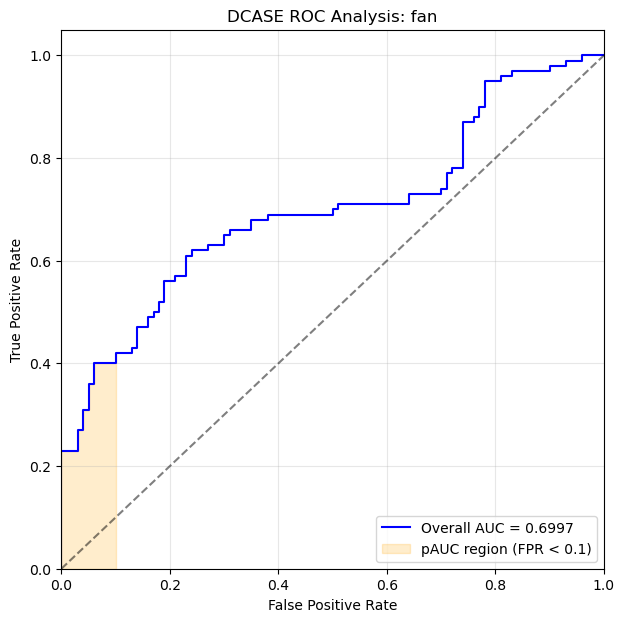

In [57]:
from scipy.stats import hmean
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare the ground truth labels
# 1 = Anomaly, 0 = Normal
df_results['y_true'] = df_results['label'].apply(lambda x: 1 if x == 'anomaly' else 0)

# 2. Split data into Anomalies and Normals (per domain)
# All anomalous clips in this section (regardless of domain)
df_anomalies = df_results[df_results['y_true'] == 1]

# Normal clips split by domain
df_normal_source = df_results[(df_results['y_true'] == 0) & (df_results['domain'] == 'source')]
df_normal_target = df_results[(df_results['y_true'] == 0) & (df_results['domain'] == 'target')]

# 3. Calculate AUC for each domain
# AUC Source = Normal Source vs All Anomalies
df_source_eval = pd.concat([df_normal_source, df_anomalies])
auc_source = metrics.roc_auc_score(df_source_eval['y_true'], df_source_eval['anomaly_score'])

# AUC Target = Normal Target vs All Anomalies
df_target_eval = pd.concat([df_normal_target, df_anomalies])
auc_target = metrics.roc_auc_score(df_target_eval['y_true'], df_target_eval['anomaly_score'])

# 4. Calculate pAUC (p=0.1) using the total set
# sklearn's max_fpr automatically normalizes the pAUC so that perfect is 1.0
p_auc = metrics.roc_auc_score(df_results['y_true'], df_results['anomaly_score'], max_fpr=0.1)

# 5. Calculate Official Score (Ω)
# The official score is the harmonic mean of the AUCs and pAUC
official_score = hmean([auc_source, auc_target, p_auc])

# --- Display Results ---
print(f"Machine: {machine}")
print(f"{'-'*30}")
print(f"AUC (Source):   {auc_source:.4f}")
print(f"AUC (Target):   {auc_target:.4f}")
print(f"pAUC (p=0.1):   {p_auc:.4f}")
print(f"{'-'*30}")
print(f"Official Score (Ω): {official_score:.4f}")

# --- Visualization ---
fpr, tpr, _ = metrics.roc_curve(df_results['y_true'], df_results['anomaly_score'])
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, label=f'Overall AUC = {metrics.roc_auc_score(df_results["y_true"], df_results["anomaly_score"]):.4f}', color='blue')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.fill_between(fpr, tpr, where=(fpr <= 0.1), alpha=0.2, label='pAUC region (FPR < 0.1)', color='orange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'DCASE ROC Analysis: {machine}')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()